In [1]:
import cupy as cp
cp.cuda.Device(2).use()
import os
## change the directory to the wholistic_registration code dir, so that we can import the modules in utils
os.chdir('/home/cyf/wbi/Virginia/code/wbi_0123/wholistic_registration/src/wholistic_registration')
from utils import IO
from utils import calFlowCrossResolution, calFlow3d_Wei_v1
from utils import registration
from utils import option
from utils import preprocess as prep
from utils import mask
from utils import  visualization


CuPy is available with CUDA - using GPU acceleration


In [2]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("/home/cyf/wbi/Virginia/code/CoarseFlow").resolve()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))
from datasets import synthetic_dataset
from training.inference import (
    CoarseFlowInferenceConfig,
    CoarseFlowPredictor,
    evaluate_coarse_and_refine_simulated_pair_with_predictor,
)

In [35]:
import json
# pth_path = "/home/cyf/wbi/Virginia/code/CoarseFlow/scripys/checkpoints/coarse_matching_v0527/best.pth"
pth_path = "/home/cyf/wbi/Virginia/code/CoarseFlow/scripys/checkpoints/coarseflow_v6_stage3b_iter3_sharpen/best.pth"

cfg = CoarseFlowInferenceConfig(
    pth_path=pth_path,
    model_config=None,
    model_module="models.SparseGMFlow3D",
    model_class="CoarseMatchingNetV5",
    device="cuda:0",      
    strict_load=True,
    use_amp=False,
)

predictor = CoarseFlowPredictor(cfg)
print("Loaded.")
print("load_msg:", predictor.load_msg)
print("model_config keys:", predictor.model_config.keys())
manifest_summary_path =  "/home/cyf/wbi/Virginia/code/CoarseFlow/cached_datasets/coarseflow_v6/manifest_summary.json"

with open(manifest_summary_path, "r") as f:
    manifest_summary = json.load(f)
val_loader_stage3, _, _ = synthetic_dataset.build_sameShape_loader(
    manifest_summary["stage3_val"],
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    drop_last=False,
    verbose=True,
)
val_loader_stage1 = synthetic_dataset.build_sameShape_loader(
    manifest_summary["stage1_val"],
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    drop_last=False,
    verbose=True,
)
val_loader_stage2 = synthetic_dataset.build_sameShape_loader(
    manifest_summary["stage2_val"],
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    drop_last=False,
    verbose=True,
)

Loaded.
load_msg: <All keys matched successfully>
model_config keys: dict_keys(['dim', 'radius', 'temperature', 'use_learned_matching', 'matcher_mode', 'control_stride', 'num_refine_iters', 'encoder_stride', 'query_chunk_size', 'moving_num_convnext_blocks', 'moving_window_attn_layers', 'ref_base_channels', 'ref_num_blocks', 'ref_refine_blocks', 'ref_use_attention', 'ref_attn_layers', 'ref_attn_num_heads', 'ref_attn_window_size', 'ref_attn_mlp_ratio', 'use_coord_embed', 'use_offset_encoding', 'use_offset_bias', 'use_local_cross_attn', 'local_attn_temperature', 'use_spacing_embed'])
[SameShapeBatchSampler] groups:
  key=(K,D,H,W)=(3, 20, 256, 256), n=39
  key=(K,D,H,W)=(3, 30, 256, 256), n=9
  key=(K,D,H,W)=(5, 20, 256, 256), n=38
  key=(K,D,H,W)=(5, 30, 256, 256), n=10
  key=(K,D,H,W)=(7, 20, 256, 256), n=37
  key=(K,D,H,W)=(7, 30, 256, 256), n=11
[SameShapeBatchSampler] groups:
  key=(K,D,H,W)=(5, 20, 256, 256), n=71
  key=(K,D,H,W)=(5, 30, 256, 256), n=19
[SameShapeBatchSampler] group

In [32]:
option_template = {
    "r": 5,
    "layer": 1,
    "iter": 10,
    "movRange": 5.0,
    "tol": 1e-8,
    "zRatio_HR": 3,
    "wrong_region_enable": False,
}
def infer_delta_ref_idx_from_batch(batch, b=0, default=10.0):
    """
    delta_ref_idx is the fixed spacing between sparse moving slices
    in reference-index units.

    If batch has z_init/sparse_z_idx, use its median difference.
    Otherwise use default.
    """
    z = None

    if "z_init" in batch:
        z = batch["z_init"][b].detach().cpu().numpy()
    elif "sparse_z_idx" in batch:
        z = batch["sparse_z_idx"][b].detach().cpu().numpy()

    if z is None:
        return float(default)

    z = np.asarray(z, dtype=np.float32).reshape(-1)

    if len(z) < 2:
        return float(default)

    dz = np.diff(z)
    dz = dz[np.isfinite(dz)]

    if dz.size == 0:
        return float(default)

    return float(np.median(np.abs(dz)))


In [33]:
rows = []
debug_outputs = []

loader = val_loader_stage3   # 换成你的 simulated val loader
max_batches = 50              # 先 debug，小心 getMotion_v2 很慢

for batch_idx, batch in enumerate(loader):
    if batch_idx >= max_batches:
        break

    mov_b = batch["mov"]   # (B,1,K,Y,X)
    ref_b = batch["ref"]   # (B,1,D,Y,X)

    B = mov_b.shape[0]

    for b in range(B):
        mov_zyx = mov_b[b, 0].detach().cpu().numpy().astype(np.float32)
        ref_zyx = ref_b[b, 0].detach().cpu().numpy().astype(np.float32)

        delta_ref_idx = infer_delta_ref_idx_from_batch(
            batch,
            b=b,
            default=10.0,
        )

        spacing = (1.0, 1.0, 1.0)
        if "spacing" in batch:
            spacing = batch["spacing"][b].detach().cpu().numpy().tolist()

        # 如果你的仿真 dataset 有 dense GT phase，可以在这里取出来
        # gt_phase_xyz = batch["gt_phase"][b].detach().cpu().numpy()
        gt_phase_xyz = None

        out = evaluate_coarse_and_refine_simulated_pair_with_predictor(
            predictor=predictor,
            mov=mov_zyx,
            ref=ref_zyx,
            delta_ref_idx=delta_ref_idx,
            calflow_module=calFlowCrossResolution,
            ref_spacing=spacing,

            normalize=True,


            use_quantile_mapping=False,
            prep_module=prep,
            mask_module=mask,

            option_template=option_template,
            thresFactor=5.0,
            maskRange=(5.0, 4000.0),
            smoothPenalty_raw=0.01,
            extra_option_updates=option_template,

            z_init=None,
            use_gradient_for_z_init=False,
            use_hann_weight_for_z_init=True,

            gt_phase_xyz=gt_phase_xyz,
            verbose=False,
        )

        row = {
            "batch_idx": batch_idx,
            "sample_idx": b,
            "delta_ref_idx": delta_ref_idx,
        }
        row.update(out["metrics"])

        rows.append(row)
        debug_outputs.append(out)

        print(
            f"[batch {batch_idx}, sample {b}] "
            f"mse_init={row['mse_init']:.6g}, "
            f"mse_coarse={row['mse_coarse']:.6g}, "
            f"mse_refine_init={row['mse_refine_init']:.6g}, "
            f"mse_refine_coarse={row['mse_refine_coarse']:.6g}, "
            f"rel_coarse_imp={row['rel_coarse_imp']:.4f}, "
            f"rel_final_imp={row['rel_final_imp']:.4f}"
        )

df_eval = pd.DataFrame(rows)
df_eval["coarse_init_gain"] = (
    df_eval["mse_init"] - df_eval["mse_coarse"]
) / (df_eval["mse_init"] + 1e-8)

df_eval["baseline_refine_gain"] = (
    df_eval["mse_init"] - df_eval["mse_refine_init"]
) / (df_eval["mse_init"] + 1e-8)

df_eval["coarse_refine_gain"] = (
    df_eval["mse_coarse"] - df_eval["mse_refine_coarse"]
) / (df_eval["mse_coarse"] + 1e-8)

df_eval["final_gain_from_coarse_init"] = (
    df_eval["mse_refine_init"] - df_eval["mse_refine_coarse"]
) / (df_eval["mse_refine_init"] + 1e-8)

df_eval["final_mse_ratio"] = (
    df_eval["mse_refine_coarse"] / (df_eval["mse_refine_init"] + 1e-8)
)
df_eval["coarse_init_gain"] = (
    df_eval["mse_init"] - df_eval["mse_coarse"]
) / (df_eval["mse_init"] + 1e-8)

df_eval["final_gain_from_coarse_init"] = (
    df_eval["mse_refine_init"] - df_eval["mse_refine_coarse"]
) / (df_eval["mse_refine_init"] + 1e-8)
df_eval

/home/cyf/wbi/Virginia/code/CoarseFlow/training/inference.py:441: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp and device.type == "cuda"):


[batch 0, sample 0] mse_init=0.021333, mse_coarse=0.00462326, mse_refine_init=0.00445423, mse_refine_coarse=0.0036464, rel_coarse_imp=0.7833, rel_final_imp=0.1814
[batch 1, sample 0] mse_init=0.0182954, mse_coarse=0.0043332, mse_refine_init=0.00597306, mse_refine_coarse=0.00511037, rel_coarse_imp=0.7632, rel_final_imp=0.1444
[batch 2, sample 0] mse_init=0.0108092, mse_coarse=0.00145138, mse_refine_init=0.00191299, mse_refine_coarse=0.00137062, rel_coarse_imp=0.8657, rel_final_imp=0.2835
[batch 3, sample 0] mse_init=0.0137717, mse_coarse=0.00337446, mse_refine_init=0.0045522, mse_refine_coarse=0.00395431, rel_coarse_imp=0.7550, rel_final_imp=0.1313
[batch 4, sample 0] mse_init=0.0233279, mse_coarse=0.0046774, mse_refine_init=0.00752693, mse_refine_coarse=0.00641472, rel_coarse_imp=0.7995, rel_final_imp=0.1478
[batch 5, sample 0] mse_init=0.011142, mse_coarse=0.00154738, mse_refine_init=0.00250576, mse_refine_coarse=0.00236753, rel_coarse_imp=0.8611, rel_final_imp=0.0552
[batch 6, sample

,batch_idx,sample_idx,delta_ref_idx,mse_init,mse_coarse,mse_refine_init,mse_refine_coarse,rel_coarse_imp,coarse_mse_ratio,rel_final_imp,final_mse_ratio,refine_gain_after_init,refine_gain_after_coarse,coarse_init_gain,baseline_refine_gain,coarse_refine_gain,final_gain_from_coarse_init
0,0,0,5.0,0.021333,0.004623,0.004454,0.003646,0.783281,0.216719,0.181362,0.818636,0.791204,0.211292,0.783281,0.791204,0.211292,0.181362
1,1,0,5.0,0.018295,0.004333,0.005973,0.005110,0.763153,0.236847,0.144430,0.855568,0.673520,-0.179352,0.763153,0.673520,-0.179352,0.144430
2,2,0,5.0,0.010809,0.001451,0.001913,0.001371,0.865727,0.134272,0.283520,0.716475,0.823022,0.055644,0.865727,0.823022,0.055644,0.283520
3,3,0,5.0,0.013772,0.003374,0.004552,0.003954,0.754971,0.245029,0.131341,0.868657,0.669452,-0.171833,0.754971,0.669452,-0.171833,0.131341
4,4,0,5.0,0.023328,0.004677,0.007527,0.006415,0.799493,0.200506,0.147764,0.852235,0.677342,-0.371430,0.799493,0.677342,-0.371430,0.147764
5,5,0,5.0,0.011142,0.001547,0.002506,0.002368,0.861120,0.138879,0.055167,0.944829,0.775105,-0.530018,0.861120,0.775105,-0.530018,0.055167
6,6,0,5.0,0.014758,0.003327,0.004132,0.003927,0.774582,0.225418,0.049390,0.950607,0.720052,-0.180569,0.774582,0.720052,-0.180569,0.049390
7,7,0,5.0,0.012081,0.001095,0.001326,0.001173,0.909326,0.090674,0.115437,0.884556,0.890268,-0.070480,0.909326,0.890268,-0.070480,0.115437
8,8,0,5.0,0.022357,0.005040,0.007354,0.005477,0.774576,0.225423,0.255212,0.744787,0.671087,-0.086712,0.774576,0.671087,-0.086712,0.255212
9,9,0,5.0,0.016135,0.001107,0.001214,0.001018,0.931361,0.068638,0.161294,0.838698,0.924769,0.080742,0.931361,0.924769,0.080742,0.161294


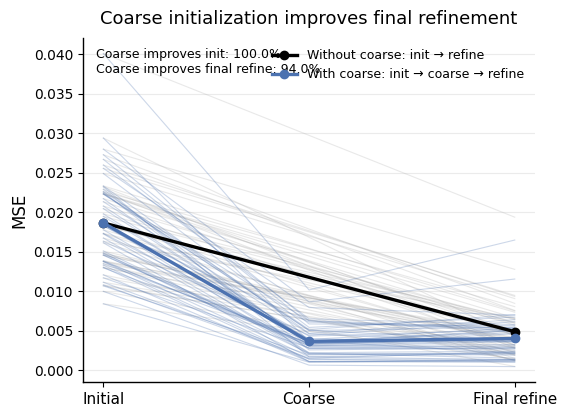

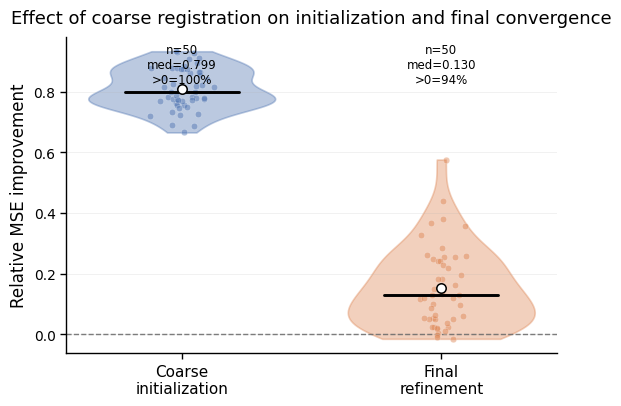

In [34]:
def plot_two_path_mse(
    df,
    use_log=True,
    figsize=(5.8, 4.3),
    title="Coarse initialization improves final refinement",
):
    import numpy as np
    import matplotlib.pyplot as plt

    x_base = np.array([0, 2], dtype=float)
    x_coarse = np.array([0, 1, 2], dtype=float)

    y_base = df[["mse_init", "mse_refine_init"]].values.astype(float)
    y_coarse = df[["mse_init", "mse_coarse", "mse_refine_coarse"]].values.astype(float)

    fig, ax = plt.subplots(figsize=figsize)

    # individual samples
    for i in range(len(df)):
        ax.plot(
            x_base,
            y_base[i],
            color="0.65",
            linewidth=0.8,
            alpha=0.25,
            zorder=1,
        )
        ax.plot(
            x_coarse,
            y_coarse[i],
            color="#4C72B0",
            linewidth=0.8,
            alpha=0.28,
            zorder=2,
        )

    # mean lines
    mean_base = np.nanmean(y_base, axis=0)
    mean_coarse = np.nanmean(y_coarse, axis=0)

    ax.plot(
        x_base,
        mean_base,
        color="black",
        marker="o",
        linewidth=2.4,
        markersize=6,
        label="Without coarse: init → refine",
        zorder=5,
    )

    ax.plot(
        x_coarse,
        mean_coarse,
        color="#4C72B0",
        marker="o",
        linewidth=2.4,
        markersize=6,
        label="With coarse: init → coarse → refine",
        zorder=6,
    )

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(
        ["Initial", "Coarse", "Final refine"],
        fontsize=11,
    )

    ax.set_ylabel("MSE")
    ax.set_title(title, pad=10)

    if use_log:
        ax.set_yscale("log")

    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, fontsize=9)

    # annotate key rates
    coarse_rate = (df["mse_coarse"] < df["mse_init"]).mean()
    final_rate = (df["mse_refine_coarse"] < df["mse_refine_init"]).mean()

    txt = (
        f"Coarse improves init: {coarse_rate:.1%}\n"
        f"Coarse improves final refine: {final_rate:.1%}"
    )

    ax.text(
        0.03,
        0.97,
        txt,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
    )

    plt.tight_layout()
    plt.show()

    return fig, ax

def plot_coarse_refine_violin(
    df,
    cols=None,
    labels=None,
    colors=None,
    ylabel="Relative MSE improvement",
    title="Coarse initialization improves refinement",
    figsize=(5.8, 4.2),
    alpha=0.38,
    show_points=True,
    point_alpha=0.45,
    point_size=22,
    jitter=0.055,
    show_zero_line=True,
    show_stats=True,
    ylim=None,
    save_path=None,
    dpi=300,
):
    """
    Paper-style violin plot for coarse/refine improvement metrics.

    Recommended cols:
        coarse_init_gain:
            (mse_init - mse_coarse) / mse_init

        final_gain_from_coarse_init:
            (mse_refine_init - mse_refine_coarse) / mse_refine_init

    Positive values mean improvement.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    if cols is None:
        cols = [
            "coarse_init_gain",
            "final_gain_from_coarse_init",
        ]

    if labels is None:
        labels = [
            "Coarse\ninitialization",
            "Final\nrefinement",
        ]

    if colors is None:
        colors = [
            "#4C72B0",  # muted blue
            "#DD8452",  # muted orange
        ]

    data = []
    for col in cols:
        vals = df[col].dropna().values.astype(float)
        data.append(vals)

    # ------------------------------------------------------------
    # Figure style
    # ------------------------------------------------------------
    plt.rcParams.update({
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 10,
        "axes.linewidth": 1.0,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    fig, ax = plt.subplots(figsize=figsize)
    positions = np.arange(1, len(cols) + 1)

    # ------------------------------------------------------------
    # Violin bodies
    # ------------------------------------------------------------
    parts = ax.violinplot(
        data,
        positions=positions,
        widths=0.72,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )

    for i, body in enumerate(parts["bodies"]):
        body.set_facecolor(colors[i])
        body.set_edgecolor(colors[i])
        body.set_alpha(alpha)
        body.set_linewidth(1.2)

    # ------------------------------------------------------------
    # Raw points
    # ------------------------------------------------------------
    rng = np.random.default_rng(123)

    if show_points:
        for i, vals in enumerate(data):
            if len(vals) == 0:
                continue

            x = rng.normal(
                loc=positions[i],
                scale=jitter,
                size=len(vals),
            )

            ax.scatter(
                x,
                vals,
                s=point_size,
                color=colors[i],
                alpha=point_alpha,
                edgecolor="white",
                linewidth=0.35,
                zorder=3,
            )

    # ------------------------------------------------------------
    # Mean / median / stats
    # ------------------------------------------------------------
    for i, vals in enumerate(data):
        if len(vals) == 0:
            continue

        x = positions[i]
        median = np.median(vals)
        mean = np.mean(vals)
        positive_rate = np.mean(vals > 0)

        # median: black horizontal line
        ax.plot(
            [x - 0.22, x + 0.22],
            [median, median],
            color="black",
            linewidth=2.1,
            solid_capstyle="round",
            zorder=5,
        )

        # mean: white dot with black edge
        ax.scatter(
            x,
            mean,
            s=46,
            color="white",
            edgecolor="black",
            linewidth=1.1,
            zorder=6,
        )

        if show_stats:
            # Put stats near the top of the axis after ylim is known later.
            # Temporarily store in axes coordinates.
            ax.text(
                x,
                0.98,
                f"n={len(vals)}\nmed={median:.3f}\n>0={positive_rate:.0%}",
                transform=ax.get_xaxis_transform(),
                ha="center",
                va="top",
                fontsize=8.5,
                color="black",
            )

    # ------------------------------------------------------------
    # Reference line: zero improvement
    # ------------------------------------------------------------
    if show_zero_line:
        ax.axhline(
            0.0,
            linestyle="--",
            linewidth=1.0,
            color="0.35",
            alpha=0.85,
            zorder=1,
        )

    # ------------------------------------------------------------
    # Axes
    # ------------------------------------------------------------
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title, pad=10)

    if ylim is not None:
        ax.set_ylim(ylim)

    ax.grid(axis="y", linestyle="-", linewidth=0.5, alpha=0.25)
    ax.grid(axis="x", visible=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", length=4, width=1.0)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        if str(save_path).lower().endswith(".png"):
            fig.savefig(str(save_path).replace(".png", ".pdf"), bbox_inches="tight")

    plt.show()

    return fig, ax



fig, ax = plot_two_path_mse(df_eval, use_log=False)

fig, ax = plot_coarse_refine_violin(
    df_eval,
    cols=[
        "coarse_init_gain",
        "final_gain_from_coarse_init",
    ],
    labels=[
        "Coarse\ninitialization",
        "Final\nrefinement",
    ],
    ylabel="Relative MSE improvement",
    title="Effect of coarse registration on initialization and final convergence",
    colors=["#4C72B0", "#DD8452"],
    ylim=None,
    save_path="./coarse_refine_improvement_violin.png",
)